Loading CLAP model...
Generating embeddings...
Shape: (10, 512)


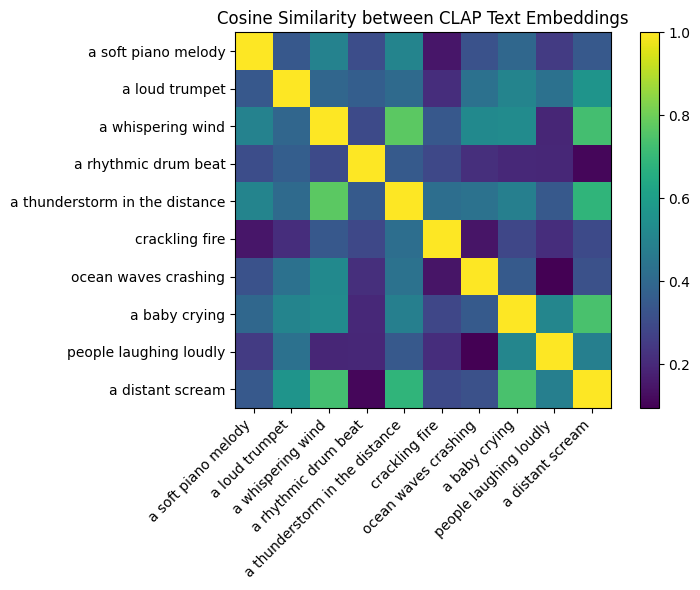

In [3]:
#CLAP Embedding Test Notebook

from transformers import ClapProcessor, ClapModel
import torch
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# Load CLAP model and processor
print("Loading CLAP model...")
processor = ClapProcessor.from_pretrained("laion/clap-htsat-unfused")
model = ClapModel.from_pretrained("laion/clap-htsat-unfused")

# Define test prompts
prompts = [
    "a soft piano melody",
    "a loud trumpet",
    "a whispering wind",
    "a rhythmic drum beat",
    "a thunderstorm in the distance",
    "crackling fire",
    "ocean waves crashing",
    "a baby crying",
    "people laughing loudly",
    "a distant scream",
]

# Generate embeddings
print("Generating embeddings...")
embeddings = []
for prompt in prompts:
    inputs = processor(text=[prompt], return_tensors="pt", padding=True)
    with torch.no_grad():
        emb = model.get_text_features(**inputs)[0].cpu().numpy()
        embeddings.append(emb)

embeddings = np.stack(embeddings)
print(f"Shape: {embeddings.shape}")

# Compute cosine similarity
sim_matrix = cosine_similarity(embeddings)

# Plot similarity matrix
plt.figure(figsize=(8, 6))
plt.imshow(sim_matrix, cmap="viridis")
plt.colorbar()
plt.xticks(ticks=range(len(prompts)), labels=prompts, rotation=45, ha='right')
plt.yticks(ticks=range(len(prompts)), labels=prompts)
plt.title("Cosine Similarity between CLAP Text Embeddings")
plt.tight_layout()
plt.show()
